# Quantum RNG oparty na fluktuacjach prozni (vacuum-fluctuation QRNG)

## Tlo teoretyczne

### 1) Fluktuacje prozni jako zrodlo entropii

W klasycznej intuicji "próznia" = "nic". W mechanice kwantowej to nie jest prawda: nawet stan podstawowy pola elektromagnetycznego ma niezerowa niepewnosc pomiaru (fluktuacje punktu zerowego, zero-point fluctuations).

Mozna to rozumiec tak:

- nie da sie jednoczesnie ustalic obu kwadratur pola (odpowiednikow amplitudy i fazy) z dowolna dokladnoscia,
- dlatego nawet idealny uklad pomiarowy zobaczy drobne, losowe odchylenia,
- te odchylenia nie wynikaja z "blednej elektroniki", tylko z samej struktury teorii kwantowej.

To wlasnie jest cenne dla QRNG: zrodlo losowosci nie opiera sie na zlozonosci algorytmu, lecz na fundamentalnej nieprzewidywalnosci wyniku pomiaru.

W praktyce mierzony sygnal jest analogowy (ciag probek o rozkladzie zblizonym do Gaussa), a potem digitalizowany i przetwarzany do bitow. Jesli tor pomiarowy jest poprawnie skalibrowany i model szumow uwzglednia skladniki klasyczne, to czesc entropii pochodzaca z fluktuacji prozni moze byc traktowana jako "fizycznie prawdziwa" losowosc.

ANU opisuje swoj serwis dokladnie w tym duchu: liczby sa generowane w czasie rzeczywistym na bazie pomiaru kwantowych fluktuacji prozni i udostepniane przez API.

### 2) Pomiar: balanced homodyne detection

Typowy vacuum-fluctuation QRNG miesza mierzony stan (proznie) z silnym lokalnym oscylatorem (laserem referencyjnym), a nastepnie odejmuje sygnaly z dwoch fotodiod (detekcja zbalansowana). W tej konfiguracji:

- skladowa kwantowa (shot-noise / vacuum-noise) jest wzmacniana przez LO,
- duza czesc wspolnego szumu klasycznego jest tlumiona przez odejmowanie,
- wynik jest szybkim analogowym strumieniem probek o rozkladzie zblizonym do Gaussa.

To podejscie wystepuje zarowno w klasycznych ukladach laboratoryjnych, jak i we wspolczesnych implementacjach zintegrowanych.

### 3) Od probki analogowej do bitow

Pipeline w vacuum-QRNG zwykle wyglada tak:

1. analogowy pomiar homodynowy,
2. digitalizacja (ADC),
3. oszacowanie entropii (konserwatywnie: min-entropia, czesto warunkowa wzgledem side information),
4. ekstrakcja losowosci (whitening/extractor),
5. testy statystyczne strumienia wyjsciowego.

W praktyce to krok 3-4 decyduje o tym, ile **bezpiecznych** bitow mozna wydzielic z jednej probki.

### 4) Model bezpieczenstwa i side information (prosciej)

Intuicyjnie: miernik zwraca nam sygnal, ale ten sygnal to mieszanka dwoch rzeczy:

- czesc **naprawde kwantowa** (ta, ktorej chcemy),
- czesc **zwykla techniczna** (elektronika, dryft, niedoskonalosci ukladu).

Sam ladny histogram nie wystarcza, bo atakujacy moze znac fragment tej "technicznej" czesci (to wlasnie **side information**).

Dlatego pytanie bezpieczenstwa brzmi nie "czy dane wygladaja losowo", tylko:

**ile losowosci zostaje nawet wtedy, gdy przeciwnik zna wszystko, co realnie moze wiedziec o torze pomiarowym?**

To jest dokladnie sens `conditional min-entropy`: konserwatywna dolna granica "bezpiecznych" bitow po uwzglednieniu informacji ubocznej.

Wniosek praktyczny: po oszacowaniu tej granicy dobiera sie ekstraktor tak, aby nie wypuscic wiecej bitow, niz rzeczywiscie gwarantuje fizyka i model szumow. Ten punkt jest kluczowy m.in. w Haw et al. (2015).


#### Mini-przyklad liczbowy (toy example)

Zalozmy, ze ADC zwraca **12 bitow** na probke (czyli surowo wyglada to na 12 bitow informacji).

Po konserwatywnej analizie side information wychodzi jednak, ze conditional min-entropy wynosi tylko **k = 7.4 bita/probke**.

To oznacza:

- surowe 1 000 000 probek daje 12 000 000 bitow danych,
- ale "bezpiecznie certyfikowalne" jest okolo 7 400 000 bitow,
- ekstraktor powinien wiec wypuscic najwyzej ~7.4 bitu/probke (z zapasem bezpieczenstwa zwykle jeszcze mniej, np. 7.0).

Czyli: **N (bity ADC) != k (bity bezpieczne)**. Roznica to cena za realistyczny model zagrozen i informacji ubocznej.


## Ograniczenia metodologiczne tej wersji

- Analizujemy **strumien po stronie API**, a nie surowy sygnal analogowy z detektora.
- Oznacza to, ze nie odtwarzamy pelnej metrologii fizycznej urzadzenia (QCNR, model toru, kalibracje, estymacja entropii z surowych danych ADC).
- W praktyce notebook pokazuje integracje i walidacje uzytkowa, a nie certyfikacje hardware-level noise source.


## Wnioski z uruchomienia (ta sesja)

Na podstawie uzyskanych wynikow walidacji:

- `bit_balance`: `p_zero=0.5002`, `p_one=0.4998` (bardzo blisko idealnego 50/50).
- `serial_pairs`: `00=4948`, `01=5056`, `10=5055`, `11=4940` (brak wyraznej asymetrii par bitow).
- Testy statystyczne skonfigurowane w projekcie: wszystkie zwrocily `pass=true`:
  - `monobit` p-value `0.9549`,
  - `runs` p-value `0.1132`,
  - `chi_square_uint64_mod_256` p-value `0.2653`,
  - `ks_uniform_floats` p-value `0.0170` (zaliczone dla progu `0.01`, ale blizej granicy niz pozostale),
  - `approximate_entropy` p-value `0.0584`.

Na podstawie wykresow, ktore zdazyly sie wygenerowac:

- Histogram floatow jest zgodny z oczekiwanym zachowaniem rozkladu bliskiego jednostajnemu (naturalne fluktuacje dla skonczenie malej probki).
- Scatter `x_n` vs `x_{n+1}` nie pokazuje widocznej regularnej struktury ani pasmowania charakterystycznego dla prostych PRNG niskiej jakosci.

### Ograniczenie API i jego wplyw na run

Sesja zostala przerwana przez `HTTP 429 (Too Many Requests)` podczas czesci wizualnej.

Statystyki pobrania z tej sesji:

- `request_count = 34`
- `downloaded_bytes = 33860`
- `logged_bytes = 33860`
- czyli lacznie `270880` bitow surowych danych API

To wyjasnia, dlaczego wygenerowaly sie tylko pierwsze dwa panele (histogram i scatter), a pozostale dwa nie zostaly domkniete.

### Referencje

1. ANU QRNG homepage: https://qrng.anu.edu.au/
2. ANU API documentation: https://qrng.anu.edu.au/contact/api-documentation/
4. J. Y. Haw et al., *Maximization of Extractable Randomness in a Quantum Random-Number Generator* (Phys. Rev. Applied 3, 054004, 2015): https://doi.org/10.1103/PhysRevApplied.3.054004


In [1]:
from datetime import datetime
from pathlib import Path

from ipow.generators import ANUVacuumQRNG
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=1000, n_bits=20000)



{
  "generator": "ANU Vacuum-Fluctuation QRNG (API)",
  "summary_numbers": {
    "count": 1000.0,
    "mean": 9.210360346230148e+18,
    "variance": 2.9944832884004087e+37,
    "std": 5.472187212075633e+18,
    "min": 3.4710439745335588e+16,
    "max": 1.8442622675584295e+19
  },
  "summary_floats": {
    "count": 1000.0,
    "mean": 0.5192359206743005,
    "variance": 0.08878513508298344,
    "std": 0.29796834577347886,
    "min": 9.403527638862652e-05,
    "max": 0.9979583586063101
  },
  "bit_balance": {
    "count": 20000,
    "zeros": 10004,
    "ones": 9996,
    "p_zero": 0.5002,
    "p_one": 0.4998
  },
  "serial_pairs": {
    "00": 4948,
    "01": 5056,
    "10": 5055,
    "11": 4940
  },
  "tests": {
    "monobit": {
      "statistic": 0.0565685424949238,
      "p_value": 0.9548888938548753,
      "pass": true
    },
    "runs": {
      "statistic": 10112.0,
      "p_value": 0.11320690238239818,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 26

HTTPError: HTTP Error 429: 

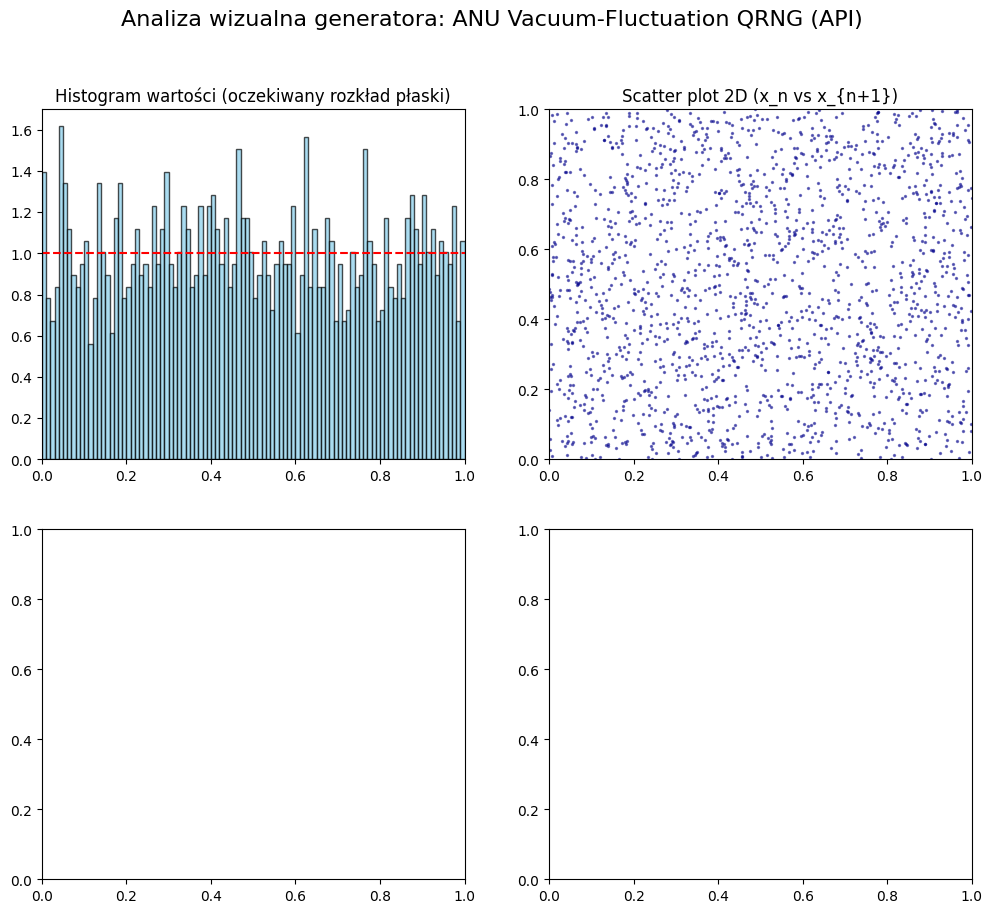

In [2]:
generator = ANUVacuumQRNG(
    api_url="https://api.quantumnumbers.anu.edu.au/",
    api_key="rdz5IvlD9Iask1prJGPnE8rH8PCtSNhP58u9ntmm",
    max_chunk=1024,
    timeout_sec=20.0,
    record_downloads=True,
)

results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))

# Dla API sieciowego zmniejszamy liczbe probek, aby ograniczyc liczbe zapytan HTTP.
run_visual_tests(generator, n_samples=1_792)

# --- Dump run artifacts for offline reuse ---
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
run_dir = Path("noteboooks") / "P7-runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)

(results_path := run_dir / "validation_results.json").write_text(
    json.dumps(results, indent=2),
    encoding="utf-8",
)

raw_path = generator.dump_download_log(str(run_dir / "api_download_uint8.bin"))
stats = generator.download_stats()

(run_dir / "run_metadata.json").write_text(
    json.dumps(
        {
            "run_id": run_id,
            "api_url": generator.api_url,
            "validation_config": {
                "n_numbers": cfg.n_numbers,
                "n_bits": cfg.n_bits,
                "approx_entropy_block_size": cfg.approx_entropy_block_size,
            },
            "visual_test_samples": 1792,
            "download_stats": stats,
            "files": {
                "validation_results": str(results_path),
                "api_download_uint8": raw_path,
            },
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Run dump saved to: {run_dir}")
print(json.dumps(stats, indent=2))



In [3]:
stats = generator.download_stats()
print(stats)


{'request_count': 34, 'downloaded_bytes': 33860, 'logged_bytes': 33860}
